In [1]:
pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 8.2 MB/s eta 0:00:00


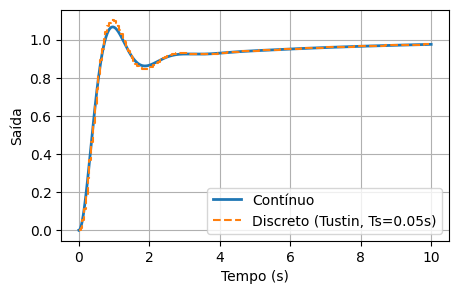

Controlador contínuo C(s):
<TransferFunction>: sys[1468]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1.19e+08 s^2 + 3.225e+08 s + 5.97e+07
  -------------------------------------
              s^2 + 1e+07 s
FTMF contínuo T(s):
<TransferFunction>: sys[1481]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                 1.19e+08 s^2 + 3.225e+08 s + 5.97e+07
  -------------------------------------------------------------------
  s^5 + 1e+07 s^4 + 6e+07 s^3 + 2.29e+08 s^2 + 3.825e+08 s + 5.97e+07

Controlador discreto C(z) via Tustin:
<TransferFunction>: sys[1478]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  490.1 z^2 - 917.6 z + 428.1
  ---------------------------
   z^2 - 0.07692 z - 0.9231

Planta discreta P(z) via ZOH:
<TransferFunction>: sys[1458]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  1.933e-05 z^2 + 7.177e-05 z + 1.664e-05
  ---------------------------------------
    z^3 - 2.717 z^2 + 2.458 z - 0.7408
FTMF discreta T(z):
<TransferFunction

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# --- Parâmetros do controlador ---
Kp = 32.25
Ki = 5.97
Kd = 11.9
Ts = 0.05  # período de amostragem
N = 1000    # fator do filtro derivativo
Nc = 10000000    # fator do filtro derivativo continuo

# --- Planta contínua ---
s=ctrl.TransferFunction.s
G = 1/((s+1)*(s+2)*(s+3))

# --- Controlador PID com filtro derivativo (forma própria) ---
C = Kp + Ki/s + (Kd*Nc*s)/(s+Nc)
C2 = Kp + Ki/s + (Kd*N*s)/(s+N)

# --- Malha fechada contínua ---
sys_cont = ctrl.feedback(C*G, 1)

# --- Converter controlador para discreto (Tustin / bilinear) ---
Cd = ctrl.c2d(C2, Ts, method='tustin')

# --- Converter planta para discreta (ZOH) ---
Gd = ctrl.c2d(G, Ts, method='zoh')

# --- Malha fechada discreta ---
sys_disc = ctrl.feedback(Cd*Gd, 1)

# --- Simulação ---
t_cont, y_cont = ctrl.step_response(sys_cont, np.linspace(0, 10, 1000))
t_disc, y_disc = ctrl.step_response(sys_disc, np.arange(0, 10, Ts))

# --- Gráfico comparativo ---
plt.figure(figsize=(5,3))
plt.plot(t_cont, y_cont, label='Contínuo', linewidth=2)
plt.step(t_disc, y_disc, where='post', label='Discreto (Tustin, Ts='+str(Ts)+'s)', linestyle='--')
#plt.title('Comparação: Resposta ao Degrau - PID Contínuo vs Discreto (Tustin)')
plt.xlabel('Tempo (s)')
plt.ylabel('Saída')
plt.grid(True)
plt.legend()
plt.show()

# --- Impressão dos controladores ---
print("Controlador contínuo C(s):")
print(C)
print("FTMF contínuo T(s):")
print(sys_cont)
print("\nControlador discreto C(z) via Tustin:")
print(Cd)
print("\nPlanta discreta P(z) via ZOH:")
print(Gd)
print("FTMF discreta T(z):")
print(sys_disc)




# --- Impressão dos coef cal manualmente

A_t=Kp+Ki*Ts/2+2*Kd/Ts
B_t=Ki*Ts/2-4*Kd/Ts
C_t=-Kp+Ki*Ts/2+2*Kd/Ts

print("A_t,B_t,C_t=", A_t,B_t,C_t)

den = N*Ts + 2.0
b0 = (2*Kd*N + (Ki*N*Ts*Ts)/2.0 + Ki*Ts + Kp*N*Ts + 2*Kp)/den
b1 = (-4*Kd*N + Ki*N*Ts*Ts - 4*Kp)/den
b2 = (2*Kd*N + (Ki*N*Ts*Ts)/2.0 - Ki*Ts - Kp*N*Ts + 2*Kp)/den
a1 = -4.0/den
a2 = (-N*Ts + 2.0)/den

print("b0, b1, b2, a1, a2=",b0, b1, b2, a1, a2)


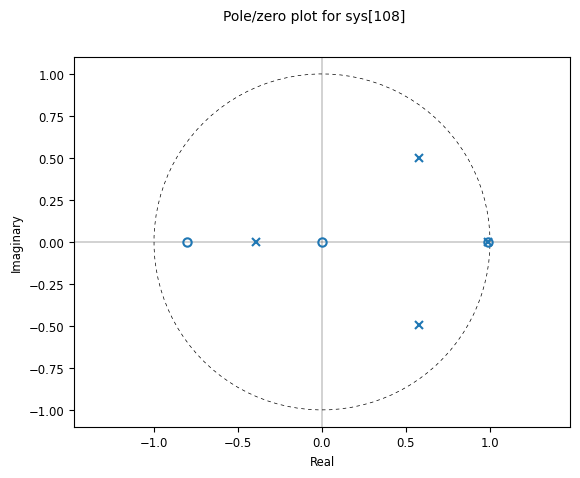

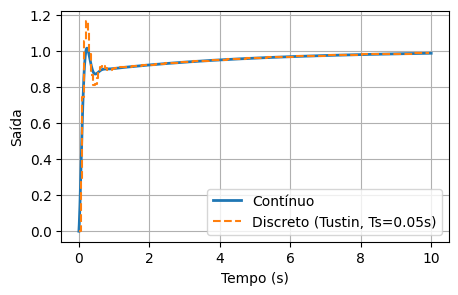

Controlador contínuo C(s):
<TransferFunction>: sys[90]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  3e+07 s^2 + 2e+09 s + 5e+08
  ---------------------------
         s^2 + 1e+07 s
FTMF contínuo T(s):
<TransferFunction>: sys[103]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             3e+07 s^2 + 2e+09 s + 5e+08
  -------------------------------------------------
  s^4 + 1e+07 s^3 + 1.6e+08 s^2 + 2.3e+09 s + 5e+08

Controlador discreto C(z) via Tustin:
<TransferFunction>: sys[100]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  287 z^2 - 283.9 z + 0.5357
  --------------------------
   z^2 - 0.5714 z - 0.4286

Planta discreta P(z) via ZOH:
<TransferFunction>: sys[80]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.001012 z + 0.0008149
  ----------------------
  z^2 - 1.467 z + 0.522
FTMF discreta T(z):
<TransferFunction>: sys[108]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

   0.2904 z^3 - 0.05347 z^2 - 0.2308 z + 0.0004366
  --------------

In [4]:
# solução do exemplo 2

import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# --- Parâmetros do controlador ---
Kp = 200
Ki = 50
Kd = 3
Ts = 0.05  # período de amostragem
N = 5/Ts    # fator do filtro derivativo
Nc = 10000000    # fator do filtro derivativo continuo

# --- Planta contínua ---
s=ctrl.TransferFunction.s
G = 1/((s+3)*(s+10))

# --- Controlador PID com filtro derivativo (forma própria) ---
C = Kp + Ki/s + (Kd*Nc*s)/(s+Nc)
C2 = Kp + Ki/s + (Kd*N*s)/(s+N)

# --- Malha fechada contínua ---
sys_cont = ctrl.feedback(C*G, 1)

# --- Converter controlador para discreto (Tustin / bilinear) ---
Cd = ctrl.c2d(C2, Ts, method='tustin')

# --- Converter planta para discreta (ZOH) ---
Gd = ctrl.c2d(G, Ts, method='zoh')

# --- Malha fechada discreta ---
sys_disc = ctrl.feedback(Cd*Gd, 1)
plt.figure()
ctrl.pzmap(sys_disc)

# --- Simulação ---
t_cont, y_cont = ctrl.step_response(sys_cont, np.linspace(0, 10, 1000))
t_disc, y_disc = ctrl.step_response(sys_disc, np.arange(0, 10, Ts))

# --- Gráfico comparativo ---
plt.figure(figsize=(5,3))
plt.plot(t_cont, y_cont, label='Contínuo', linewidth=2)
plt.step(t_disc, y_disc, where='post', label='Discreto (Tustin, Ts='+str(Ts)+'s)', linestyle='--')
#plt.title('Comparação: Resposta ao Degrau - PID Contínuo vs Discreto (Tustin)')
plt.xlabel('Tempo (s)')
plt.ylabel('Saída')
plt.grid(True)
plt.legend()
plt.show()

# --- Impressão dos controladores ---
print("Controlador contínuo C(s):")
print(C)
print("FTMF contínuo T(s):")
print(sys_cont)
print("\nControlador discreto C(z) via Tustin:")
print(Cd)
print("\nPlanta discreta P(z) via ZOH:")
print(Gd)
print("FTMF discreta T(z):")
print(sys_disc)
# --- Impressão dos coef cal manualmente
b0 = (2*Kd*N + (Ki*N*Ts*Ts)/2.0 + Ki*Ts + Kp*N*Ts + 2*Kp)/(N*Ts + 2.0)
b1 = (-4*Kd*N + Ki*N*Ts*Ts - 4*Kp)/(N*Ts + 2.0)
b2 = (2*Kd*N + (Ki*N*Ts*Ts)/2.0 - Ki*Ts - Kp*N*Ts + 2*Kp)/(N*Ts + 2.0)
a1 = -4.0/(N*Ts + 2.0)
a2 = (-N*Ts + 2.0)/(N*Ts + 2.0)

print("\n coef PID digital: b0, b1, b2, a1, a2=",b0, b1, b2, a1, a2)
